# Section 0 — Imports & setup

- Mount Drive, import libraries
- Load `llm_results`, `nlp_results` pickles
- Define `EMOTIONS`, `TASTES`, constants
- Download Kaggle dataset, build `image_lookup`

In [ ]:
import os, glob, re, pickle, io
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns
from PIL import Image

from scipy.stats import spearmanr, gaussian_kde
from sklearn.manifold import TSNE
from scipy.spatial.distance import jensenshannon

from google.colab import drive
drive.mount('/content/drive')

print('All imports OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports OK


In [ ]:
# Label lists
EMOTIONS = [
    'Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied',
    'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy'
]
TASTES = ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']

EMOTIONS_LOWER = [e.lower() for e in EMOTIONS]
TASTES_LOWER   = [t.lower() for t in TASTES]
N_BOOKS        = 60

# Colour maps
EMOTION_COLORS = {
    'happy':'#97C459','pleasure':'#5DCAA5','astonished':'#FAC775',
    'relaxed':'#85B7EB','satisfied':'#AFA9EC','tired':'#B4B2A9',
    'fear':'#F09595','angry':'#E24B4A','annoyed':'#D85A30',
    'sad':'#378ADD','disgust':'#639922','droopy':'#888780',
}
EMOTION_PALETTE = {k.capitalize(): v for k, v in EMOTION_COLORS.items()}
TASTE_PALETTE = {
    'Sweet':'#F4C0D1','Sour':'#C0DD97','Salty':'#B5D4F4',
    'Bitter':'#D3D1C7','Umami':'#FAC775',
}

# File paths
EMOTION_FILE = '/content/drive/MyDrive/user-study/20260327_Conjointly_experiment_646348.xlsx'
TASTE_FILE   = '/content/drive/MyDrive/user-study/20260327_Conjointly_experiment_646190.xlsx'
MAPPING_FILE = '/content/drive/MyDrive/user-study/q_to_book_mapping.xlsx'
IMAGE_FOLDER = '/content/drive/MyDrive/latest_llm'

print(f'Emotions ({len(EMOTIONS)}): {EMOTIONS}')
print(f'Tastes   ({len(TASTES)}):   {TASTES}')


Emotions (12): ['Happy', 'Pleasure', 'Astonished', 'Relaxed', 'Satisfied', 'Tired', 'Fear', 'Angry', 'Annoyed', 'Sad', 'Disgust', 'Droopy']
Tastes   (5):   ['Sweet', 'Sour', 'Salty', 'Bitter', 'Umami']


In [ ]:
# Load CLIP / NLP results
with open('/content/drive/MyDrive/dataset/llm_rankings.pkl', 'rb') as f:
    llm_results = pickle.load(f)
with open('/content/drive/MyDrive/dataset/nlp_rankings.pkl', 'rb') as f:
    nlp_results = pickle.load(f)

print('LLM emotions:', list(llm_results['emotion'].keys()))
print('LLM tastes:  ', list(llm_results['taste'].keys()))

# Kaggle image lookup (ISBN filename → Kaggle cache path)
import kagglehub
dataset_path = kagglehub.dataset_download('mexwell/book-cover-dataset')
all_kaggle = (
    glob.glob(os.path.join(dataset_path, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(dataset_path, '**/*.png'),  recursive=True)
)
image_lookup = {os.path.basename(p): p for p in all_kaggle}
print(f'Kaggle images indexed: {len(image_lookup):,}')

# Local image lookup (renamed files in latest_llm → full path)
all_local = (
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpg'),  recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.jpeg'), recursive=True) +
    glob.glob(os.path.join(IMAGE_FOLDER, '**/*.png'),  recursive=True)
)
local_lookup = {os.path.basename(p): p for p in all_local}
print(f'Local images indexed:  {len(local_lookup):,}')

LLM emotions: ['happy', 'pleasure', 'astonished', 'relaxed', 'satisfied', 'tired', 'fear', 'angry', 'annoyed', 'sad', 'disgust', 'droopy']
LLM tastes:   ['sweet', 'sour', 'salty', 'bitter', 'umami']
Using Colab cache for faster access to the 'book-cover-dataset' dataset.
Kaggle images indexed: 57,000
Local images indexed:  60


In [ ]:
# Helper functions

def resolve_path(fname):
    """Try .jpg / .jpeg / .png extensions in local_lookup."""
    fname = str(fname)
    for ext in ['.jpg', '.jpeg', '.png']:
        p = local_lookup.get(fname + ext)
        if p: return p
    return None

def sort_key(fname):
    """Sort filenames like 6_r3 → (6, 3) for group ordering."""
    m = re.match(r'(\d+)_r(\d+)', str(fname))
    return (int(m.group(1)), int(m.group(2))) if m else (99, 99)

def load_human_study(filepath, q_pattern, label_list, valid_q_nums):
    """
    valid_q_nums: set of Q numbers from mapping file marked as real books.
    Only processes those Q numbers — skips trials AND quality tests.
    """
    df = pd.read_excel(filepath, sheet_name='Respondents', header=1)
    df.columns = df.iloc[0]
    df = df.iloc[1:].reset_index(drop=True)
    completed = df[df['Status of response'] == 'Completed survey'].copy()
    print(f'  Completed respondents: {len(completed)}')

    q_cols = [c for c in df.columns if isinstance(c, str)
              and re.search(q_pattern, c) and 'Option' not in c]
    print(f'  Total question columns found: {len(q_cols)}')

    results = []
    skipped = 0
    for col in q_cols:
        q_match = re.match(r'Q(\d+)', col)
        if not q_match: continue
        q_num = int(q_match.group(1))

        # Only process Q numbers that are real books in the mapping
        if q_num not in valid_q_nums:
            skipped += 1
            continue

        counts  = Counter(completed[col].dropna().str.strip().str.lower())
        n_votes = sum(counts.values())
        top1    = counts.most_common(1)[0][0] if counts else None
        prob_vector = np.zeros(len(label_list))
        if n_votes > 0:
            for i, label in enumerate(label_list):
                prob_vector[i] = counts.get(label.lower(), 0) / n_votes
        results.append({
            'q_num':         q_num,
            'top1':          top1,
            'probabilities': prob_vector,
            'vote_counts':   dict(counts),
            'n_votes':       n_votes,
        })

    print(f'  Real book columns processed: {len(results)} (skipped {skipped} trials/quality tests)')
    return results

def plot_matrix_with_thumbs(matrix, row_labels, image_paths, border_emotions,
                             title, cmap, fmt, vmin=None, vmax=None,
                             matrix_h=5.0, savefile=None):
    """Render a heatmap with book cover thumbnails on top."""
    n_books = matrix.shape[0]
    THUMB_H = 0.8; TOTAL_W = 30
    fig = plt.figure(figsize=(TOTAL_W, 0.4 + THUMB_H + matrix_h))
    gs  = gridspec.GridSpec(3, n_books,
            height_ratios=[0.4, THUMB_H, matrix_h], hspace=0.02, wspace=0.05)
    ax_title = fig.add_subplot(gs[0, :])
    ax_title.axis('off')
    ax_title.text(0.5, 0.5, title, ha='center', va='center',
                  fontsize=13, transform=ax_title.transAxes)
    for col_i, (path, em) in enumerate(zip(image_paths, border_emotions)):
        ax_img = fig.add_subplot(gs[1, col_i])
        ax_img.axis('off')
        color = EMOTION_COLORS.get(str(em).lower(), '#ccc')
        for spine in ax_img.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2); spine.set_visible(True)
        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB')
                img.thumbnail((80, 120))
                ax_img.imshow(np.array(img), aspect='auto')
            except: ax_img.set_facecolor('#eee')
        else: ax_img.set_facecolor('#eee')
    df = pd.DataFrame(matrix.T, index=row_labels,
                      columns=[f'B{i+1:02d}' for i in range(n_books)])
    ax_heat = fig.add_subplot(gs[2, :])
    kwargs = dict(ax=ax_heat, annot=True, fmt=fmt, annot_kws={'size': 6},
                  cmap=cmap, linewidths=0.8, linecolor='white', cbar=False)
    if vmin is not None: kwargs['vmin'] = vmin
    if vmax is not None: kwargs['vmax'] = vmax
    sns.heatmap(df, **kwargs)
    ax_heat.set_xlabel('')
    ax_heat.set_ylabel('', fontsize=11)
    ax_heat.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_heat.tick_params(axis='y', rotation=0, labelsize=9)
    if savefile: plt.savefig(savefile, dpi=150, bbox_inches='tight')
    plt.show()

def tsne_with_covers(coords, labels, palette, title, image_paths, savefile, thumb_size=(28, 42)):
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.set_title(title, fontsize=14, pad=20)

    # Set axis limits based on data range
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0) # Sets the initial scale

    # Add each image as an AnnotationBbox
    for i in range(len(coords)):
        path = image_paths[i]
        label = labels[i]
        color = palette.get(label, '#cccccc')

        if path and os.path.exists(path):
            try:
                # Load and resize image
                img = Image.open(path).convert('RGB')
                img.thumbnail(thumb_size)

                # Create the Image Box
                # 'pad' adds space for the border
                imagebox = OffsetImage(img, zoom=1.0)
                imagebox.image.axes = ax

                # Create the Annotation Box pinned to data coordinates (coords[i])
                ab = AnnotationBbox(imagebox, (coords[i, 0], coords[i, 1]),
                                    xycoords='data',
                                    frameon=True,
                                    pad=0.3,
                                    bboxprops=dict(edgecolor=color, lw=3))
                ax.add_artist(ab)
            except Exception as e:
                continue

    # Standard formatting
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.spines[['top', 'right']].set_visible(False)

    # Legend
    handles = [mpatches.Patch(color=palette[l], label=l) for l in sorted(set(labels))]
    ax.legend(handles=handles, fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(savefile, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_va_covers(va, labels, palette, title, image_paths, savefile,
                   thumb_size=(60, 94), padding=0.05):

    v_min = va[:,0].min()-padding; v_max = va[:,0].max()+padding
    a_min = va[:,1].min()-padding; a_max = va[:,1].max()+padding

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('Valence  (negative ← → positive)', fontsize=10)
    ax.set_ylabel('Arousal  (calm ← → intense)', fontsize=10)
    ax.spines[['top','right']].set_visible(False)

    # Quadrant shading
    # Q1 (+val +aro): excited/happy — warm yellow
    ax.fill_between([0, v_max], 0, a_max, color='#FFF9C4', alpha=0.5, zorder=0)
    # Q2 (-val +aro): stressed/fearful — warm red
    ax.fill_between([v_min, 0], 0, a_max, color='#FFEBEE', alpha=0.5, zorder=0)
    # Q3 (-val -aro): sad/depressed — cool blue
    ax.fill_between([v_min, 0], a_min, 0, color='#E3F2FD', alpha=0.5, zorder=0)
    # Q4 (+val -aro): calm/relaxed — soft green
    ax.fill_between([0, v_max], a_min, 0, color='#E8F5E9', alpha=0.5, zorder=0)

    # Crosshairs
    ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--', zorder=1)
    ax.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--', zorder=1)

    # Quadrant labels
    ax.text(0.97, 0.97, 'Q1\nHappy/Excited',   transform=ax.transAxes, ha='right', va='top',    fontsize=8, color='#888')
    ax.text(0.03, 0.97, 'Q2\nStressed/Fearful', transform=ax.transAxes, ha='left',  va='top',    fontsize=8, color='#888')
    ax.text(0.03, 0.03, 'Q3\nSad/Depressed',    transform=ax.transAxes, ha='left',  va='bottom', fontsize=8, color='#888')
    ax.text(0.97, 0.03, 'Q4\nCalm/Relaxed',     transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#888')

    ax.set_xlim(v_min, v_max); ax.set_ylim(a_min, a_max)
    ax.scatter(va[:,0], va[:,1], alpha=0)
    ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                        for l in sorted(set(labels))],
              fontsize=9, bbox_to_anchor=(1.01,1), loc='upper left')

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    canvas = Image.open(buf).copy()
    buf.close()
    W, H = canvas.size
    AX_L, AX_R = int(0.09*W), int(0.82*W)
    AX_T, AX_B = int(0.08*H), int(0.92*H)
    tw, th = thumb_size

    for i in range(len(va)):
        label     = labels[i]
        color_hex = palette.get(label, '#cccccc')
        color_rgb = tuple(int(color_hex.lstrip('#')[j*2:j*2+2], 16) for j in range(3))
        cx = int(AX_L + (va[i,0]-v_min)/(v_max-v_min)*(AX_R-AX_L))
        cy = int(AX_T + (a_max-va[i,1])/(a_max-a_min)*(AX_B-AX_T))
        path = image_paths[i] if image_paths else None
        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB').resize((tw, th))
                border = 3
                bordered = Image.new('RGB', (tw+2*border, th+2*border), color_rgb)
                bordered.paste(img, (border, border))
                canvas.paste(bordered, (cx-tw//2-border, cy-th//2-border))
            except: pass

    canvas.save(savefile)
    print(f'Saved: {savefile}')
    fig2, ax2 = plt.subplots(figsize=(12, 9))
    ax2.imshow(np.array(canvas)); ax2.axis('off')
    plt.tight_layout(); plt.show(); plt.close(fig2)

# Section 1 — NLP vs CLIP agreement (Spearman)

- Spearman correlation function + compute for emotion & taste
- Bar chart visualisation
- Summary stats printout

In [ ]:
def compute_spearman(nlp_rankings, llm_rankings):
    results = []

    for label, nlp_data in nlp_rankings.items():
        if label not in llm_rankings:
            continue

        llm_data = llm_rankings[label]

        # Pre-calculate rank positions using dictionary (much faster than using nested for loops)
        # This maps: {'filename': rank_position}
        nlp_map = {fname: i + 1 for i, (fname, _) in enumerate(nlp_data)}
        llm_map = {fname: i + 1 for i, (fname, _) in enumerate(llm_data)}

        # Find common books using Set intersection
        common = set(nlp_map.keys()).intersection(llm_map.keys())

        if len(common) < 3:
            continue

        # Extract ranks only for common books
        # We convert to a list to ensure the order is identical for both arrays
        common_list = list(common)
        nlp_ranks = [nlp_map[b] for b in common_list]
        llm_ranks = [llm_map[b] for b in common_list]

        # Compute correlation
        rho, pval = spearmanr(nlp_ranks, llm_ranks)

        results.append({
            'Label': label,
            'Spearman ρ': round(rho, 4),
            'p-value': round(pval, 4),
            'Significant': '✓' if pval < 0.05 else '✗',
            'N books': len(common)
        })

    return pd.DataFrame(results).set_index('Label')

# Run the faster version
emotion_spearman = compute_spearman(nlp_results['emotion'], llm_results['emotion'])
taste_spearman   = compute_spearman(nlp_results['taste'],   llm_results['taste'])

print('Emotion:\n', emotion_spearman.to_string())
print('\nTaste:\n',  taste_spearman.to_string())

Emotion:
            Spearman ρ  p-value Significant  N books
Label                                              
happy          0.9116      0.0           ✓    56185
pleasure       0.9432      0.0           ✓    56185
relaxed        0.9170      0.0           ✓    56185
satisfied      0.8678      0.0           ✓    56185
tired          0.7765      0.0           ✓    56185
fear           0.8787      0.0           ✓    56185
angry          0.8807      0.0           ✓    56185
annoyed        0.9211      0.0           ✓    56185
sad            0.9277      0.0           ✓    56185
disgust        0.8600      0.0           ✓    56185
droopy         0.9239      0.0           ✓    56185

Taste:
         Spearman ρ  p-value Significant  N books
Label                                           
sweet       0.7507      0.0           ✓    56185
sour        0.9078      0.0           ✓    56185
salty       0.7605      0.0           ✓    56185
bitter      0.6465      0.0           ✓    56185
umami      

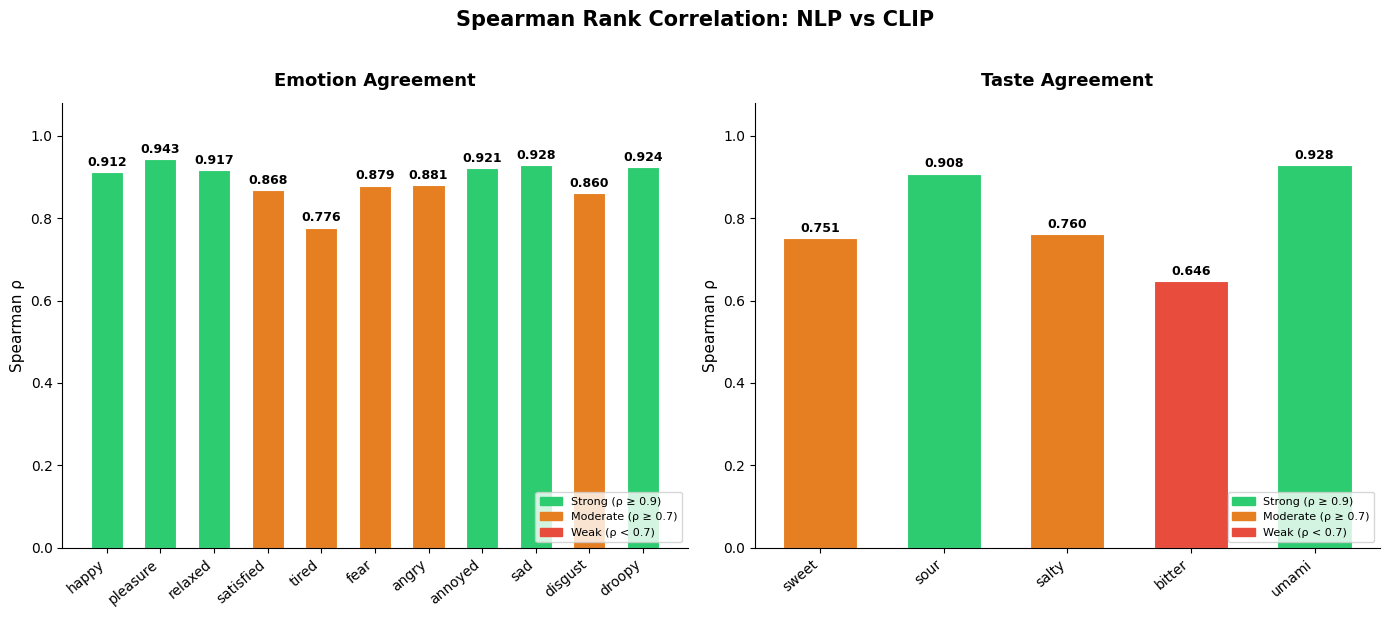

Emotion: mean=0.8917  max=0.9432 (pleasure)  sig=11/11
Taste: mean=0.7988  max=0.9283 (umami)  sig=5/5


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (df, title) in zip(axes, [(emotion_spearman, 'Emotion Agreement'),
                                   (taste_spearman,   'Taste Agreement')]):
    rhos   = df['Spearman ρ'].values
    colors = ['#2ecc71' if r>=0.9 else '#e67e22' if r>=0.7 else '#e74c3c' for r in rhos]
    bars   = ax.bar(range(len(rhos)), rhos, color=colors, width=0.6,
                    edgecolor='white', linewidth=0.8)
    for bar, rho in zip(bars, rhos):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{rho:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(rhos)))
    ax.set_xticklabels(df.index, rotation=40, ha='right', fontsize=10)
    ax.set_ylim(0, 1.08); ax.set_ylabel('Spearman ρ', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13, pad=12)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(handles=[
        mpatches.Patch(color='#2ecc71', label='Strong (ρ ≥ 0.9)'),
        mpatches.Patch(color='#e67e22', label='Moderate (ρ ≥ 0.7)'),
        mpatches.Patch(color='#e74c3c', label='Weak (ρ < 0.7)'),
    ], fontsize=8, loc='lower right')
fig.suptitle('Spearman Rank Correlation: NLP vs CLIP', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

for name, df in [('Emotion', emotion_spearman), ('Taste', taste_spearman)]:
    rhos = df['Spearman ρ']
    print(f'{name}: mean={rhos.mean():.4f}  max={rhos.max():.4f} ({rhos.idxmax()})  '
          f'sig={(df["p-value"]<0.05).sum()}/{len(df)}')


# Section 2 — Build CLIP matrices

- Build 60-book pool (greedy top-5 per emotion)
- Build binary emotion matrix (60×12) and taste matrix (60×5)
- Build raw score emotion matrix (60×12) and taste matrix (60×5)

- Heatmap: binary emotion
- Heatmap: binary taste
- Heatmap: raw score emotion
- Heatmap: raw score taste

In [ ]:
# 60-book pool (greedy top-5 per emotion, no repeats)
pool_entries = []; used = set()
for emotion_label in EMOTIONS_LOWER:
    key = emotion_label
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None: continue
    added = 0
    for fname, score in llm_results['emotion'][key]:
        if fname not in used and added < 5:
            pool_entries.append({'fname': fname, 'fpath': image_lookup.get(fname),
                                 'clip_emotion': emotion_label, 'emotion_score': score})
            used.add(fname); added += 1

# Top-1 CLIP taste per book
taste_score_lookup = {t: {f: s for f, s in llm_results['taste'][t]} for t in TASTES_LOWER}
for entry in pool_entries:
    ts = {t: taste_score_lookup[t].get(entry['fname'], -999) for t in TASTES_LOWER}
    entry['clip_taste'] = max(ts, key=ts.get)

N = len(pool_entries)
pool_image_paths = [e['fpath']        for e in pool_entries]
pool_emotions    = [e['clip_emotion'] for e in pool_entries]

# Binary matrices
clip_emotion_matrix = np.zeros((N, len(EMOTIONS)), dtype=int)
clip_taste_matrix   = np.zeros((N, len(TASTES)),   dtype=int)
for i, entry in enumerate(pool_entries):
    e = 'astonished' if 'astonish' in entry['clip_emotion'] else entry['clip_emotion']
    t = entry['clip_taste']
    if e in EMOTIONS_LOWER: clip_emotion_matrix[i, EMOTIONS_LOWER.index(e)] = 1
    if t in TASTES_LOWER:   clip_taste_matrix[i,   TASTES_LOWER.index(t)]   = 1

# Raw score matrices
clip_emotion_scores = np.zeros((N, len(EMOTIONS_LOWER)), dtype=float)
for j, em in enumerate(EMOTIONS_LOWER):
    key = em
    if key not in llm_results['emotion']:
        alt = [k for k in llm_results['emotion'] if 'astonish' in k]
        key = alt[0] if alt else None
    if key is None: continue
    sd = {f: s for f, s in llm_results['emotion'][key]}
    for i, e in enumerate(pool_entries): clip_emotion_scores[i, j] = sd.get(e['fname'], 0.0)

clip_taste_scores = np.zeros((N, len(TASTES_LOWER)), dtype=float)
for j, ta in enumerate(TASTES_LOWER):
    sd = {f: s for f, s in llm_results['taste'][ta]}
    for i, e in enumerate(pool_entries): clip_taste_scores[i, j] = sd.get(e['fname'], 0.0)

# Normalised probability matrices
clip_emotion_probs = clip_emotion_scores / clip_emotion_scores.sum(axis=1, keepdims=True)
clip_taste_probs   = clip_taste_scores   / clip_taste_scores.sum(axis=1, keepdims=True)
clip_top1_emotion  = [EMOTIONS[i] for i in clip_emotion_probs.argmax(axis=1)]
clip_top1_taste    = [TASTES[i]   for i in clip_taste_probs.argmax(axis=1)]

missing = sum(1 for p in pool_image_paths if p is None)
print(f'Pool: {N} books | images resolved: {N-missing}/{N}')
print(f'clip_emotion_matrix: {clip_emotion_matrix.shape}')
print(f'clip_taste_matrix:   {clip_taste_matrix.shape}')
print(f'clip_emotion_scores: {clip_emotion_scores.shape}')
print(f'clip_taste_scores:   {clip_taste_scores.shape}')


Pool: 60 books | images resolved: 60/60
clip_emotion_matrix: (60, 12)
clip_taste_matrix:   (60, 5)
clip_emotion_scores: (60, 12)
clip_taste_scores:   (60, 5)


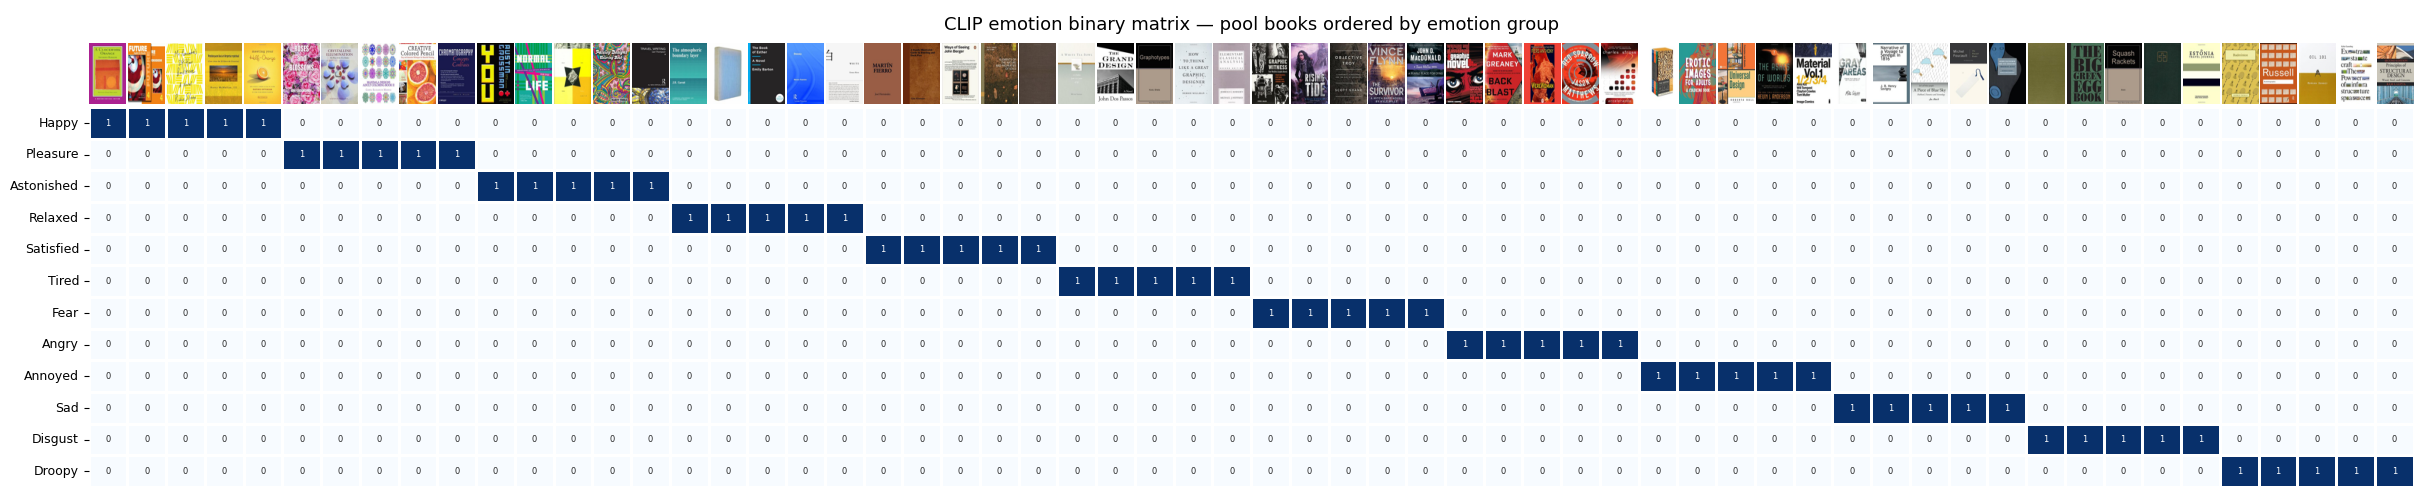

In [ ]:
# CLIP emotion binary heatmap
plot_matrix_with_thumbs(
    clip_emotion_matrix, EMOTIONS, pool_image_paths, pool_emotions,
    'CLIP emotion binary matrix — pool books ordered by emotion group',
    cmap='Blues', fmt='', vmin=0, vmax=1, matrix_h=5.0,
    savefile='clip_emotion_binary_matrix.png'
)


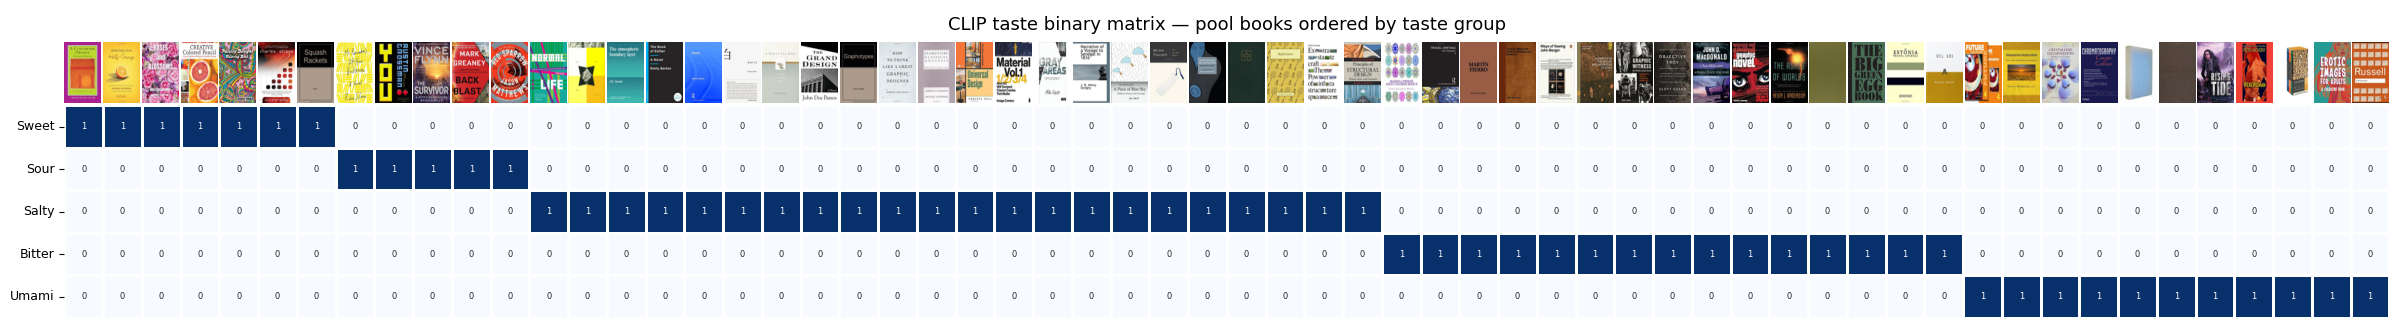

In [ ]:
# CLIP taste binary heatmap

taste_order = np.argsort(clip_taste_matrix.argmax(axis=1), kind='stable')

plot_matrix_with_thumbs(
    clip_taste_matrix[taste_order, :],
    TASTES,
    [pool_image_paths[i] for i in taste_order],
    [pool_emotions[i]    for i in taste_order],
    'CLIP taste binary matrix — pool books ordered by taste group',
    cmap='Blues', fmt='', vmin=0, vmax=1, matrix_h=2.8,
    savefile='clip_taste_binary_matrix.png'
)


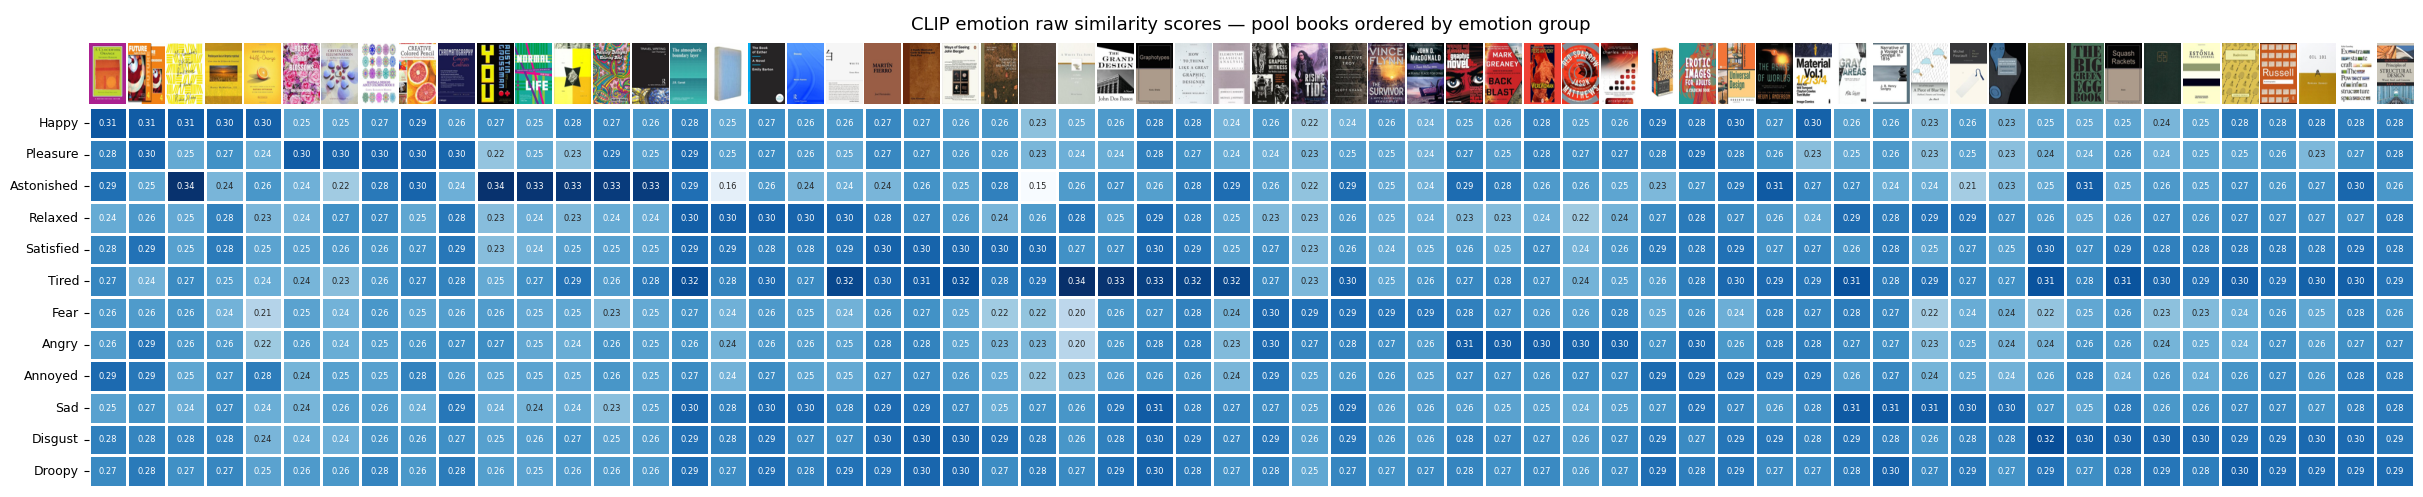

In [ ]:
# CLIP emotion raw scores heatmap
plot_matrix_with_thumbs(
    clip_emotion_scores, EMOTIONS, pool_image_paths, pool_emotions,
    'CLIP emotion raw similarity scores — pool books ordered by emotion group',
    cmap='Blues', fmt='.2f', matrix_h=5.0,
    savefile='clip_emotion_raw_scores.png'
)


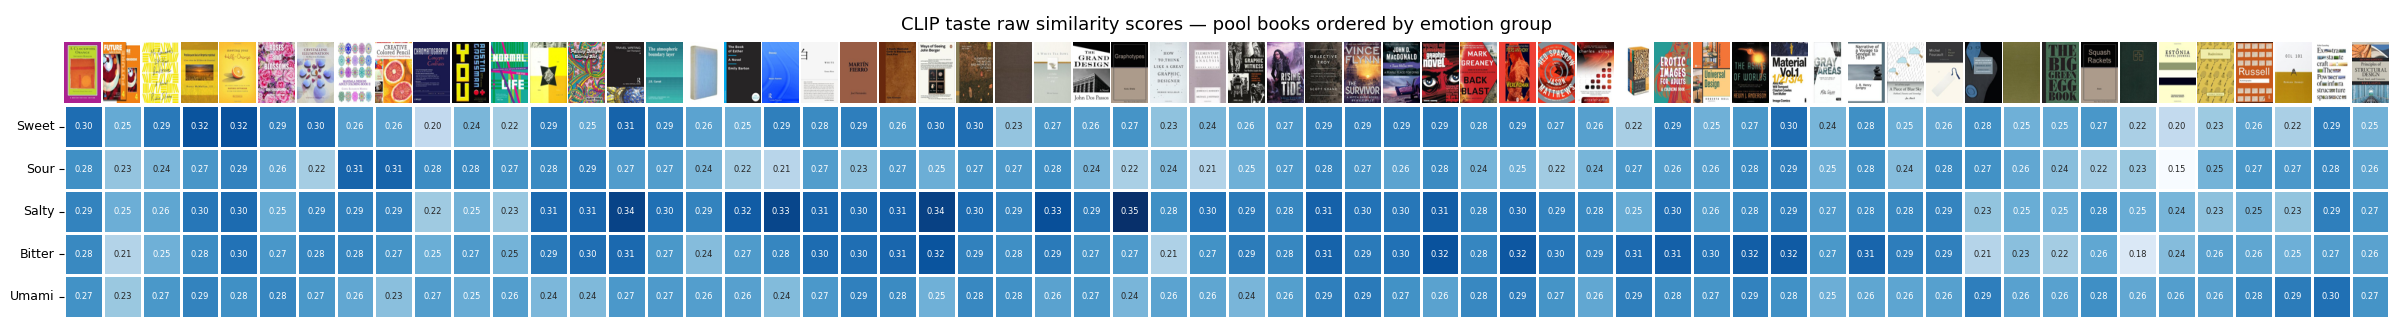

In [ ]:
# CLIP taste raw scores heatmap

taste_order_raw = np.argsort(clip_taste_matrix.argmax(axis=1), kind='stable')

plot_matrix_with_thumbs(
    clip_taste_scores[taste_order_raw, :], TASTES, pool_image_paths, pool_emotions,
    'CLIP taste raw similarity scores — pool books ordered by emotion group',
    cmap='Blues', fmt='.2f', matrix_h=2.8,
    savefile='clip_taste_raw_scores.png'
)


# Section 3 — Build human study matrices

- Load Conjointly Excel files
- Load mapping file (q_to_book_mapping.xlsx)
- load_plurality_votes() for emotion study
- load_plurality_votes() for taste study
- Join by book title using mapping file
- Build human binary emotion matrix (60×12)
- Build human binary taste matrix (60×5)
- Heatmap: human emotion
- Heatmap: human taste

In [ ]:
valid_emotion_qs = set(real_books['emotion_Q (study 646348)'].dropna().astype(int))
valid_taste_qs   = set(real_books['taste_Q (study 646190)'].dropna().astype(int))

print('Loading emotion study...')
human_emotion_data = load_human_study(
    EMOTION_FILE, r'Book Cover Emotion Survey$',
    EMOTIONS_LOWER, valid_emotion_qs
)

print('Loading taste study...')
human_taste_data = load_human_study(
    TASTE_FILE, r'Book Cover Taste Association$',
    TASTES_LOWER, valid_taste_qs
)

Loading emotion study...
  Completed respondents: 62
  Total question columns found: 62
  Real book columns processed: 60 (skipped 2 trials/quality tests)
Loading taste study...
  Completed respondents: 56
  Total question columns found: 62
  Real book columns processed: 60 (skipped 2 trials/quality tests)


In [ ]:
# Load mapping & build all human matrices
mapping    = pd.read_excel(MAPPING_FILE)
real_books = mapping[mapping['is_trial'] == 'No'].copy()

em_sorted = real_books.sort_values('emotion_Q (study 646348)').reset_index(drop=True)
ta_sorted = real_books.sort_values('taste_Q (study 646190)').reset_index(drop=True)

all_filenames = em_sorted['image_filename'].tolist()
fname_to_idx  = {f: i for i, f in enumerate(all_filenames)}
N_BOOKS       = len(all_filenames)

# Q number → result lookup
em_q_to_result = {b['q_num']: b for b in human_emotion_data}
ta_q_to_result = {b['q_num']: b for b in human_taste_data}

# Binary and probability matrices
emotion_matrix      = np.zeros((N_BOOKS, len(EMOTIONS)), dtype=int)
taste_matrix        = np.zeros((N_BOOKS, len(TASTES)),   dtype=int)
human_emotion_probs = np.zeros((N_BOOKS, len(EMOTIONS)), dtype=float)
human_taste_probs   = np.zeros((N_BOOKS, len(TASTES)),   dtype=float)

for i, row in em_sorted.iterrows():
    q_num = int(row['emotion_Q (study 646348)']) if pd.notna(row['emotion_Q (study 646348)']) else None
    row_i = fname_to_idx.get(row['image_filename'])
    if q_num is None or row_i is None: continue
    book = em_q_to_result.get(q_num)
    if book is None: continue
    human_emotion_probs[row_i] = book['probabilities']

    # Handle ties — assign 1 to ALL labels with the max vote count
    if book['vote_counts']:
        max_votes = max(book['vote_counts'].values())
        for label, count in book['vote_counts'].items():
            if count == max_votes:
                label_clean = label.lower().strip()
                if label_clean in EMOTIONS_LOWER:
                    emotion_matrix[row_i, EMOTIONS_LOWER.index(label_clean)] = 1

for i, row in ta_sorted.iterrows():
    q_num = int(row['taste_Q (study 646190)']) if pd.notna(row['taste_Q (study 646190)']) else None
    row_i = fname_to_idx.get(row['image_filename'])
    if q_num is None or row_i is None: continue
    book = ta_q_to_result.get(q_num)
    if book is None: continue
    human_taste_probs[row_i] = book['probabilities']

    if book['vote_counts']:
        max_votes = max(book['vote_counts'].values())
        for label, count in book['vote_counts'].items():
            if count == max_votes:
                label_clean = label.lower().strip()
                if label_clean in TASTES_LOWER:
                    taste_matrix[row_i, TASTES_LOWER.index(label_clean)] = 1

human_top1_emotion = [EMOTIONS[i] for i in human_emotion_probs.argmax(axis=1)]
human_top1_taste   = [TASTES[i]   for i in human_taste_probs.argmax(axis=1)]

# ── Sort by filename group order (0_r1 … 11_r5) ───────────────────────────────
def _sort_df(df):
    d = df.copy()
    d['_sort'] = d['image_filename'].apply(sort_key)
    return d.sort_values('_sort').reset_index(drop=True)

em_sorted_by_group = _sort_df(em_sorted)
ta_sorted_by_group = _sort_df(ta_sorted)

em_col_order = [fname_to_idx[r['image_filename']]
                for _, r in em_sorted_by_group.iterrows()
                if r['image_filename'] in fname_to_idx]
ta_col_order = [fname_to_idx[r['image_filename']]
                for _, r in ta_sorted_by_group.iterrows()
                if r['image_filename'] in fname_to_idx]

emotion_matrix_sorted = emotion_matrix[em_col_order, :]
taste_matrix_sorted   = taste_matrix[ta_col_order, :]

human_emotion_image_paths = [resolve_path(r['image_filename'])
                              for _, r in em_sorted_by_group.iterrows()]
human_taste_image_paths   = [resolve_path(r['image_filename'])
                              for _, r in ta_sorted_by_group.iterrows()]

def _border(df):
    if 'clip_emotion' in df.columns:
        return [str(r.get('clip_emotion','')).lower() for _, r in df.iterrows()]
    return [''] * len(df)

em_border = _border(em_sorted_by_group)
ta_border = _border(ta_sorted_by_group)

print(f'N_BOOKS:             {N_BOOKS}')
print(f'emotion_matrix:      {emotion_matrix.shape}')
print(f'taste_matrix:        {taste_matrix.shape}')
print(f'human_emotion_probs: {human_emotion_probs.shape}')
print(f'human_taste_probs:   {human_taste_probs.shape}')
print(f'em images resolved:  {sum(1 for p in human_emotion_image_paths if p)}/{N_BOOKS}')
print(f'ta images resolved:  {sum(1 for p in human_taste_image_paths   if p)}/{N_BOOKS}')

N_BOOKS:             60
emotion_matrix:      (60, 12)
taste_matrix:        (60, 5)
human_emotion_probs: (60, 12)
human_taste_probs:   (60, 5)
em images resolved:  60/60
ta images resolved:  60/60


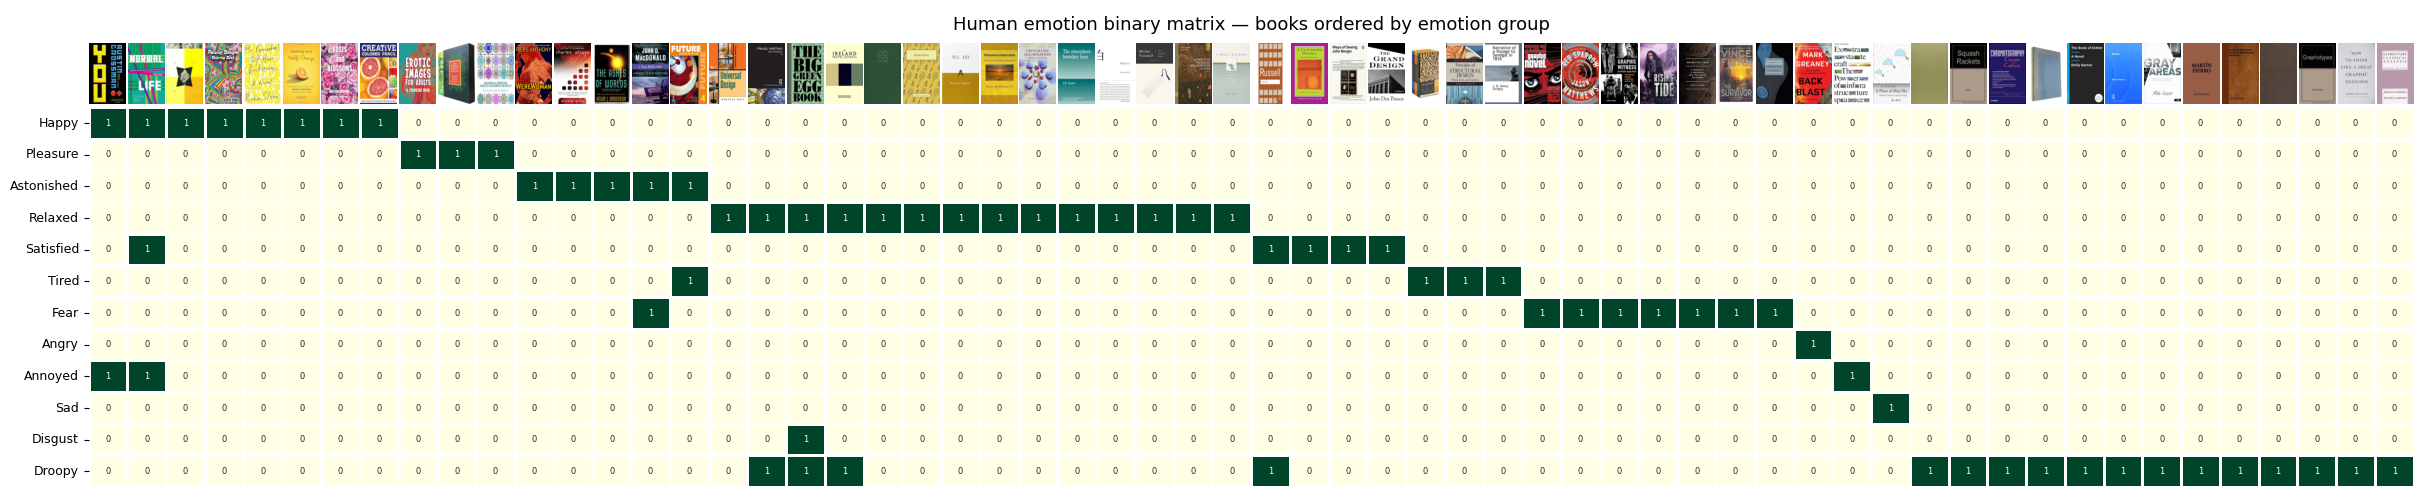

In [ ]:
# Human emotion binary heatmap
human_em_order = np.argsort(emotion_matrix_sorted.argmax(axis=1), kind='stable')
plot_matrix_with_thumbs(
    emotion_matrix_sorted[human_em_order, :], EMOTIONS,
    [human_emotion_image_paths[i] for i in human_em_order],
    [em_border[i] for i in human_em_order],
    'Human emotion binary matrix — books ordered by emotion group',
    cmap='YlGn', fmt='d', vmin=0, vmax=1, matrix_h=5.0,
    savefile='human_emotion_binary_matrix.png'
)


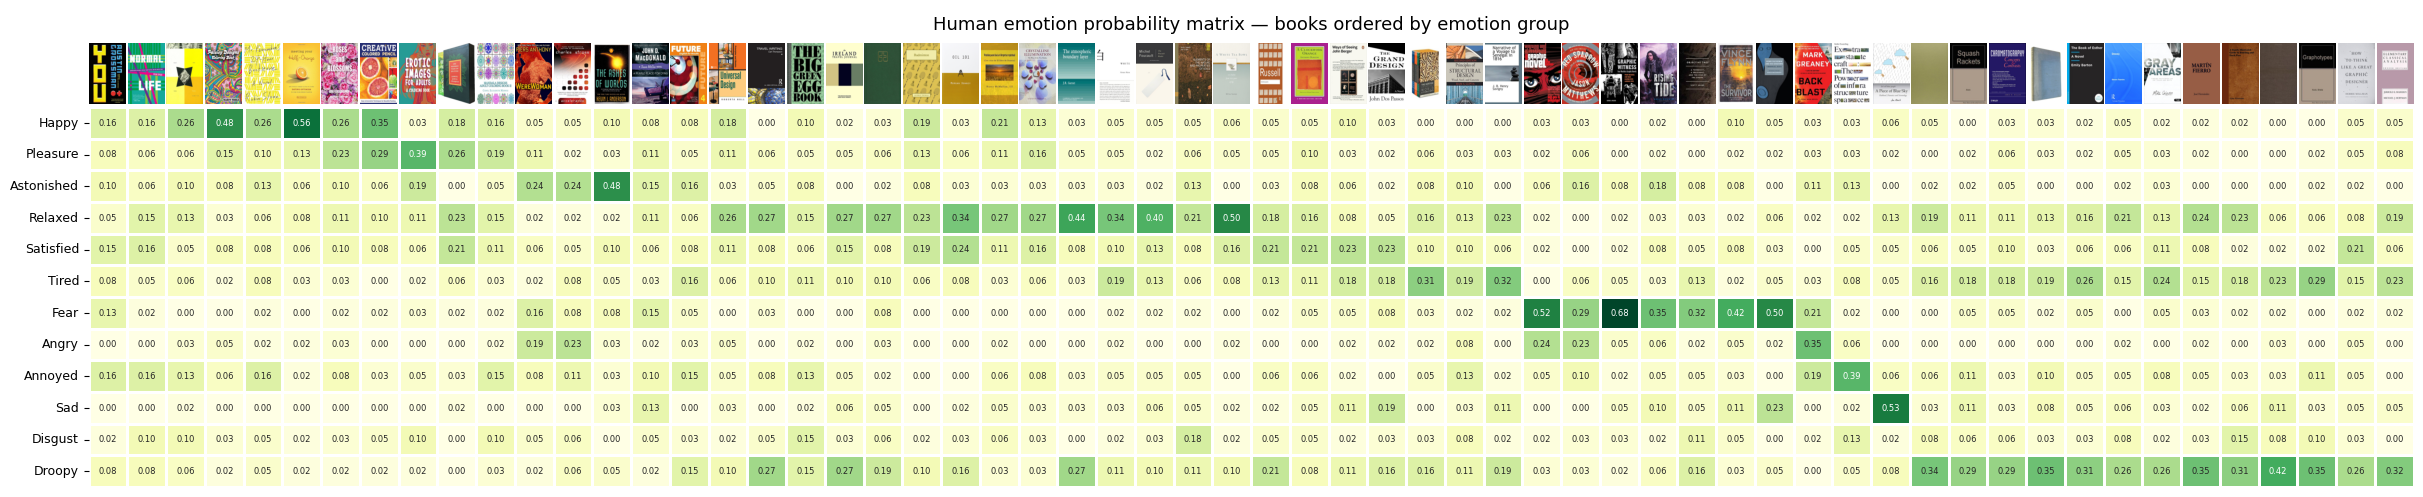

In [ ]:
# Human emotion probability heatmap
human_em_prob_order = np.argsort(
    human_emotion_probs[em_col_order, :].argmax(axis=1),
    kind='stable'
)

plot_matrix_with_thumbs(
    human_emotion_probs[em_col_order, :][human_em_prob_order, :], EMOTIONS,
    [human_emotion_image_paths[i] for i in human_em_prob_order],
    [em_border[i] for i in human_em_prob_order],
    'Human emotion probability matrix — books ordered by emotion group',
    cmap='YlGn', fmt='.2f', matrix_h=5.0,
    savefile='human_emotion_prob_matrix.png'
)

In [ ]:
# CHECK CHECK CHECK
# Find the graphic novel (Q11 → image 0_r1 → fname_to_idx position 0)

book_row = human_emotion_probs[fname_to_idx['0_r1']]
print('Graphic novel (0_r1 / Q11) emotion probabilities:')
for label, prob in zip(EMOTIONS, book_row):
    if prob > 0:
        print(f'  {label:12s}: {prob:.3f}')

# Expected values: Fear=0.516, Angry=0.242, Astonished=0.065

Graphic novel (0_r1 / Q11) emotion probabilities:
  Happy       : 0.032
  Pleasure    : 0.016
  Astonished  : 0.065
  Relaxed     : 0.016
  Satisfied   : 0.016
  Fear        : 0.516
  Angry       : 0.242
  Annoyed     : 0.048
  Disgust     : 0.016
  Droopy      : 0.032


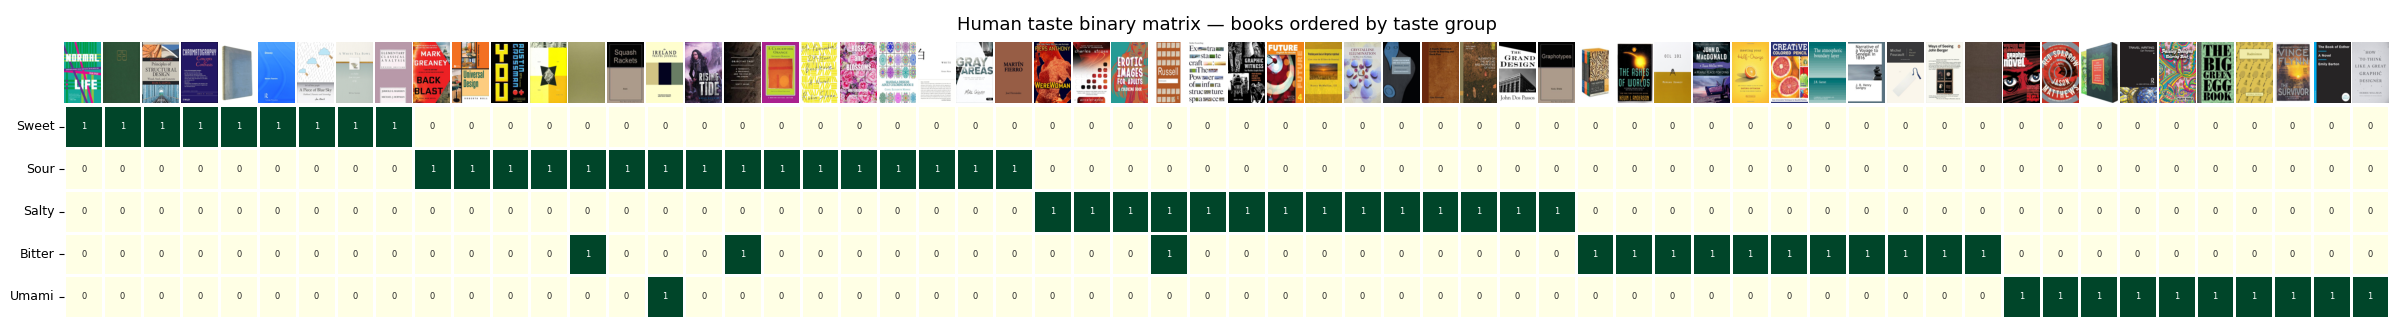

In [ ]:
# Human taste binary heatmap
human_taste_order = np.argsort(taste_matrix_sorted.argmax(axis=1), kind='stable')
plot_matrix_with_thumbs(
    taste_matrix_sorted[human_taste_order, :], TASTES,
    [human_taste_image_paths[i] for i in human_taste_order],
    [ta_border[i] for i in human_taste_order],
    'Human taste binary matrix — books ordered by taste group',
    cmap='YlGn', fmt='d', vmin=0, vmax=1, matrix_h=2.8,
    savefile='human_taste_binary_matrix.png'
)

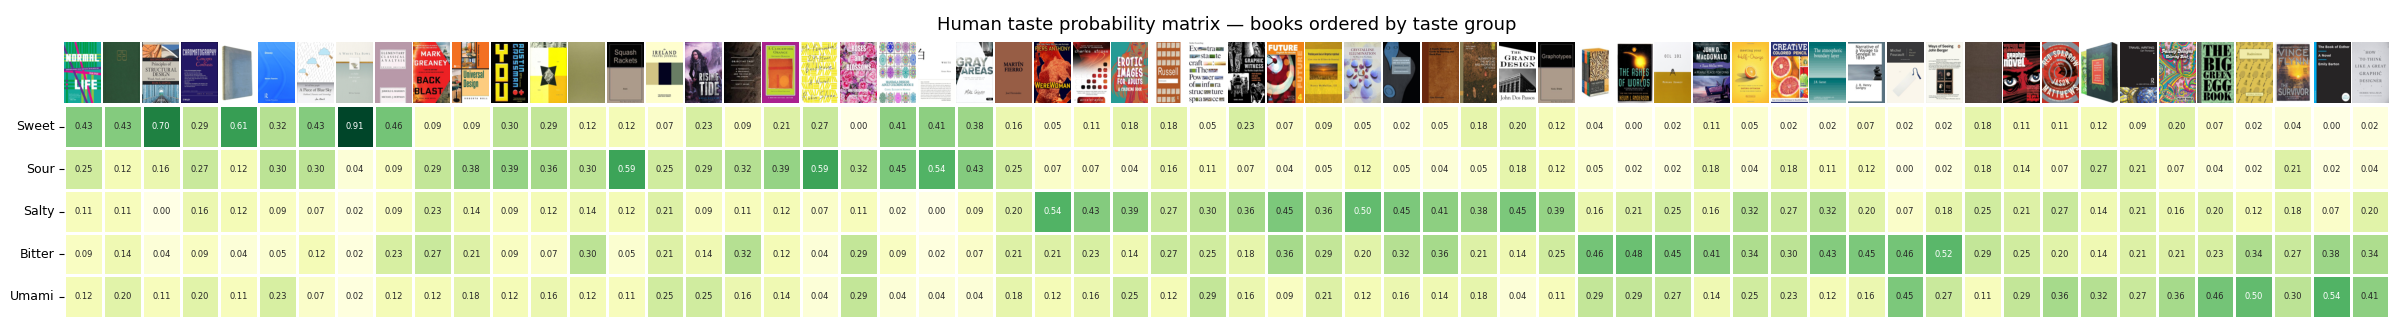

In [ ]:
# Human taste prob heatmap
human_ta_prob_order = np.argsort(
    human_taste_probs[ta_col_order, :].argmax(axis=1),
    kind='stable'
)

plot_matrix_with_thumbs(
    human_taste_probs[ta_col_order, :][human_ta_prob_order, :], TASTES,
    [human_taste_image_paths[i] for i in human_ta_prob_order],
    [ta_border[i] for i in human_ta_prob_order],
    'Human taste probability matrix — books ordered by taste group',
    cmap='YlGn', fmt='.2f', matrix_h=2.8,
    savefile='human_taste_prob_matrix.png'
)

# Section 4 — t-SNE visualisations

In [ ]:
# Pre-cache all thumbnails at small size
thumbnail_cache = {}

all_paths = set(
    [p for p in pool_image_paths          if p] +
    [p for p in human_emotion_image_paths if p] +
    [p for p in human_taste_image_paths   if p]
)

for path in all_paths:
    if os.path.exists(path):
        try:
            img = Image.open(path).convert('RGB')
            img.thumbnail((20, 30))
            thumbnail_cache[path] = np.array(img)
        except:
            pass

print(f'Cached {len(thumbnail_cache)} thumbnails')

Cached 120 thumbnails


In [ ]:


def tsne_with_covers(coords, labels, palette, title, image_paths,
                     savefile, thumb_size=(40, 57)):
    """PIL-based t-SNE with KDE shaded background regions per label group."""

    fig, ax = plt.subplots(figsize=(12, 9))
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

    # Set axis limits first
    pad = 2
    x_min, x_max = coords[:,0].min()-pad, coords[:,0].max()+pad
    y_min, y_max = coords[:,1].min()-pad, coords[:,1].max()+pad
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ── KDE contour regions per label group ───────────────────────────────────
    xx, yy = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])

    for label in sorted(set(labels)):
        mask = np.array([l == label for l in labels])
        pts  = coords[mask]
        if pts.shape[0] < 2: continue
        color = palette.get(label, '#cccccc')
        try:
            kde = gaussian_kde(pts.T, bw_method=0.4)
            zz  = kde(grid_coords).reshape(xx.shape)
            zz  = (zz - zz.min()) / (zz.max() - zz.min() + 1e-10)

            # Filled region (subtle)
            ax.contourf(xx, yy, zz,
                        levels=[0.25, 1.0],
                        colors=[color], alpha=0.15, zorder=0)
            # Outline (bold)
            ax.contour(xx, yy, zz,
                       levels=[0.25],
                       colors=[color], linewidths=1.8,
                       linestyles='solid', zorder=1)
        except: continue

    # Legend
    ax.legend(handles=[mpatches.Patch(color=palette[l], label=l)
                        for l in sorted(set(labels))],
              fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()

    # Render to PIL canvas then paste covers
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    canvas = Image.open(buf).copy()
    buf.close()
    W, H = canvas.size
    AX_L, AX_R = int(0.09*W), int(0.82*W)
    AX_T, AX_B = int(0.08*H), int(0.92*H)
    tw, th = thumb_size

    for i in range(len(coords)):
        label     = labels[i]
        color_hex = palette.get(label, '#cccccc')
        color_rgb = tuple(int(color_hex.lstrip('#')[j*2:j*2+2], 16) for j in range(3))
        cx = int(AX_L + (coords[i,0]-x_min)/(x_max-x_min)*(AX_R-AX_L))
        cy = int(AX_T + (y_max-coords[i,1])/(y_max-y_min)*(AX_B-AX_T))
        path = image_paths[i] if image_paths else None
        if path and os.path.exists(path):
            try:
                img = Image.open(path).convert('RGB').resize((tw, th))
                border = 3
                bordered = Image.new('RGB', (tw+2*border, th+2*border), color_rgb)
                bordered.paste(img, (border, border))
                canvas.paste(bordered, (cx-tw//2-border, cy-th//2-border))
            except: pass

    canvas.save(savefile)
    print(f'Saved: {savefile}')
    fig2, ax2 = plt.subplots(figsize=(12, 9))
    ax2.imshow(np.array(canvas)); ax2.axis('off')
    plt.tight_layout(); plt.show(); plt.close(fig2)

In [ ]:
# Run t-SNE and plot with book cover thumbnails
def run_tsne(matrix, perplexity=10, random_state=42):
    return TSNE(n_components=2, perplexity=perplexity,
                random_state=random_state, max_iter=1000).fit_transform(matrix)

coords_clip_em  = run_tsne(clip_emotion_probs)
coords_clip_ta  = run_tsne(clip_taste_probs)
coords_human_em = run_tsne(human_emotion_probs)
coords_human_ta = run_tsne(human_taste_probs)


Saved: tsne_clip_emotion.png


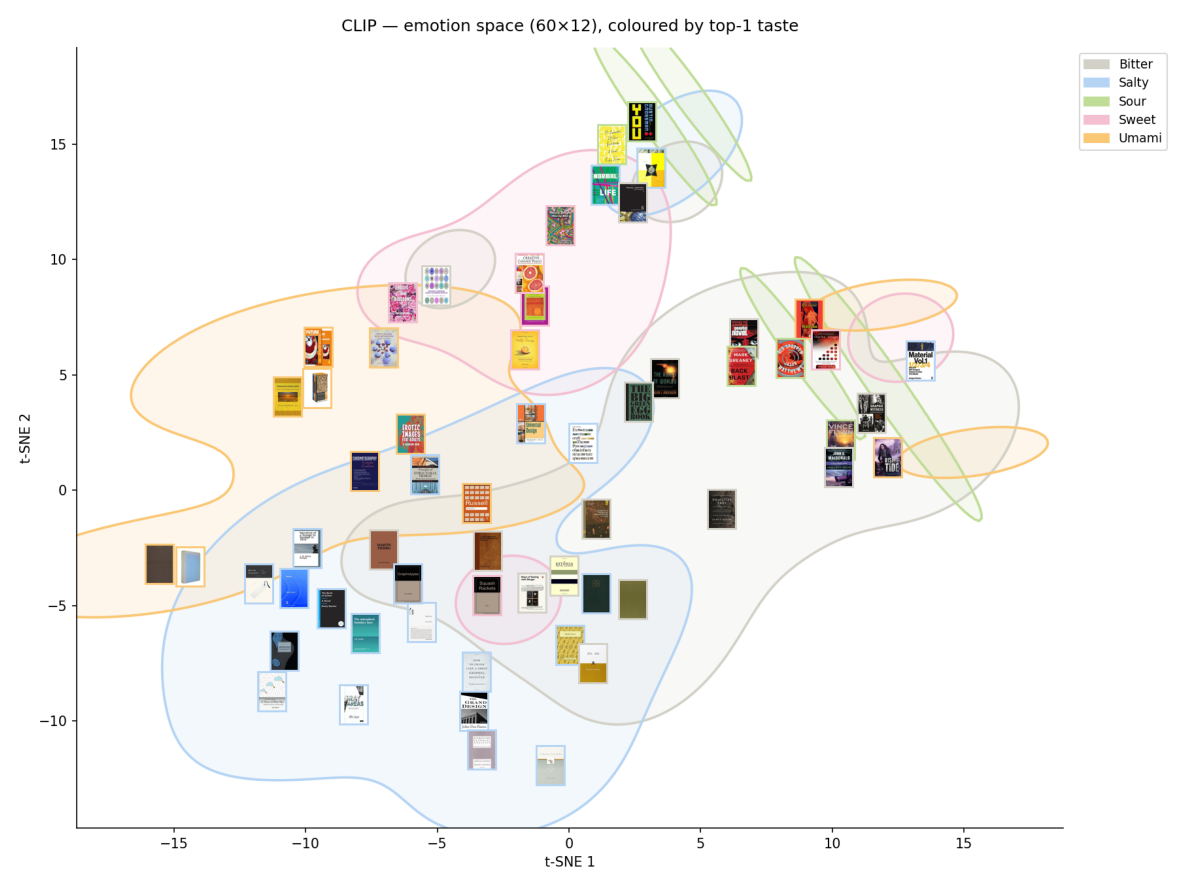

In [ ]:
# CLIP on emotion space
tsne_with_covers(coords_clip_em, clip_top1_taste, TASTE_PALETTE,
                        'CLIP — emotion space (60×12), coloured by top-1 taste',
                        pool_image_paths, savefile='tsne_clip_emotion.png')

Saved: tsne_human_emotion.png


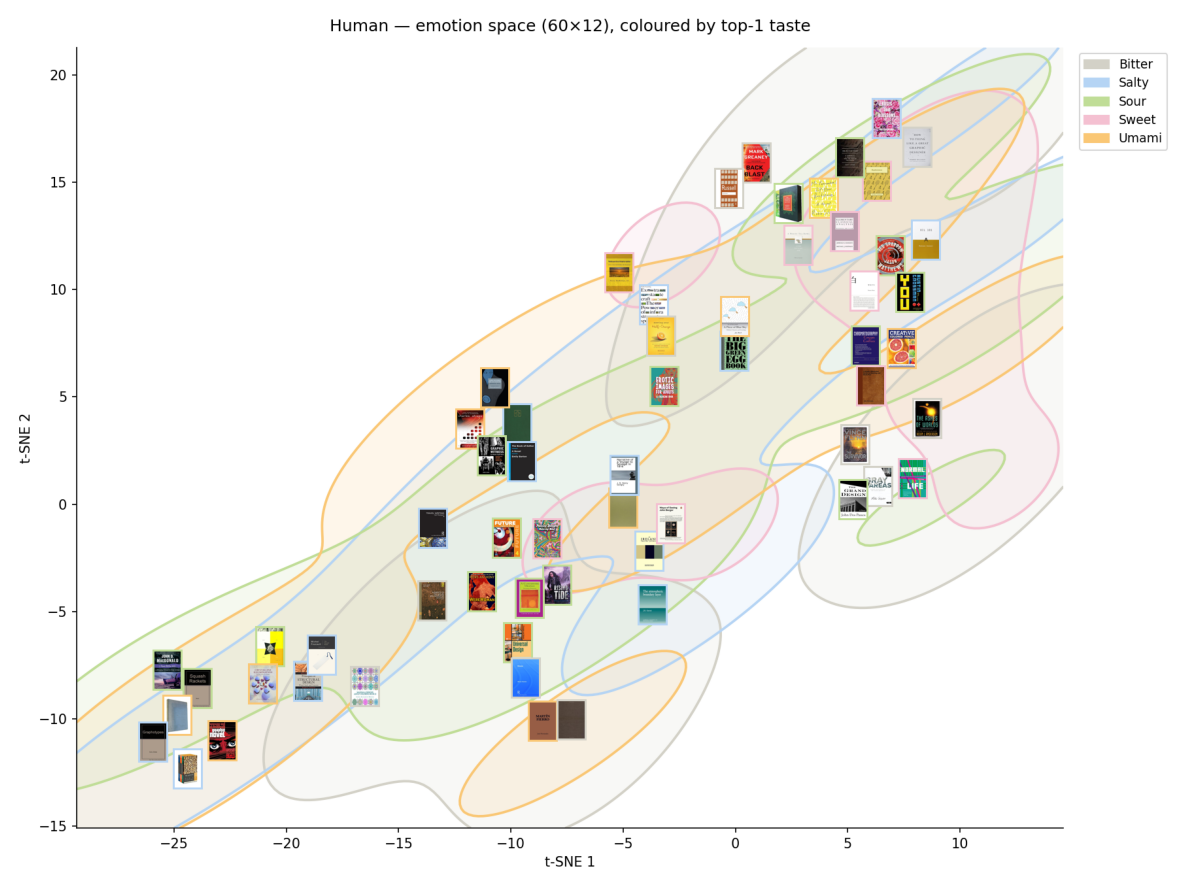

In [ ]:
# Human study on emotion space
tsne_with_covers(coords_human_em, human_top1_taste,TASTE_PALETTE,
                 'Human — emotion space (60×12), coloured by top-1 taste',
                 human_emotion_image_paths,
                 savefile='tsne_human_emotion.png')

Saved: tsne_clip_taste.png


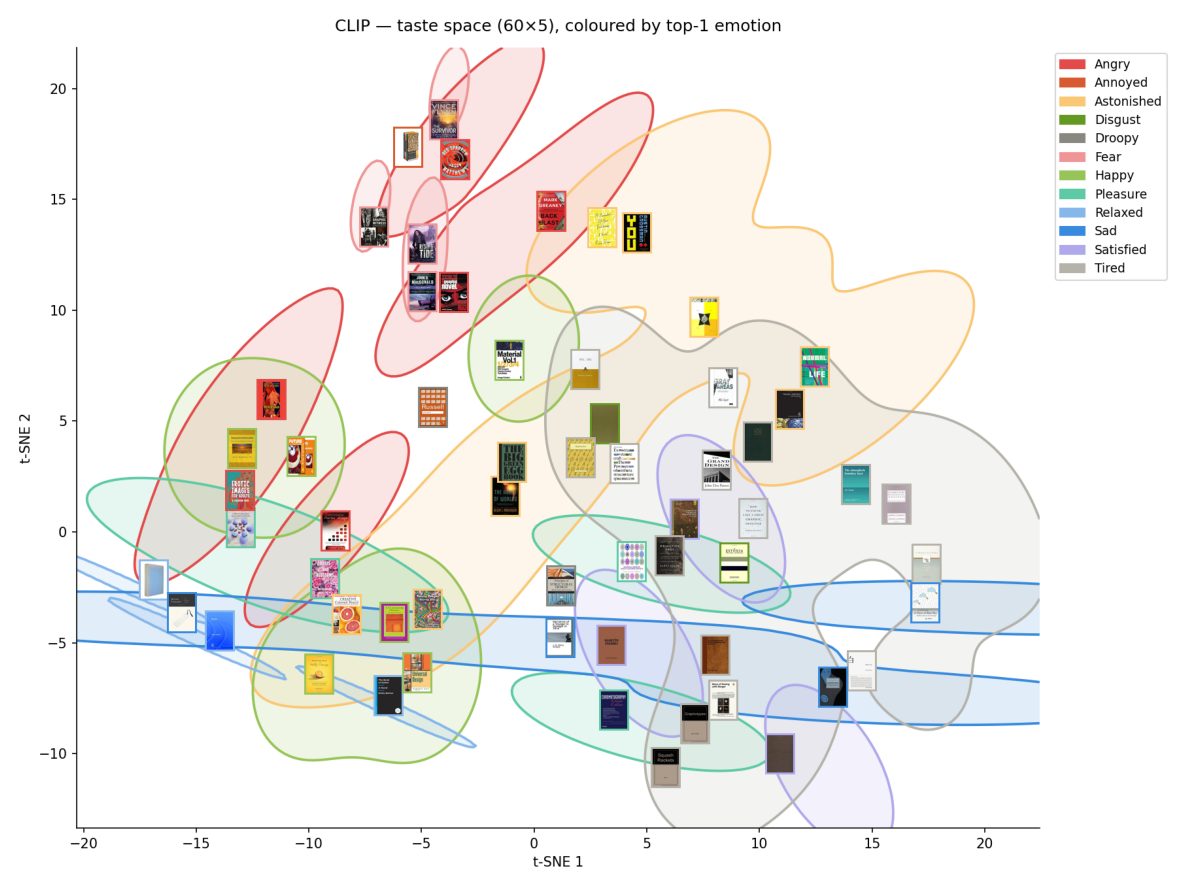

In [ ]:
# CLIP on taste space
tsne_with_covers(coords_clip_ta, clip_top1_emotion,EMOTION_PALETTE,
                 'CLIP — taste space (60×5), coloured by top-1 emotion',
                 pool_image_paths,
                 savefile='tsne_clip_taste.png')

Saved: tsne_human_taste.png


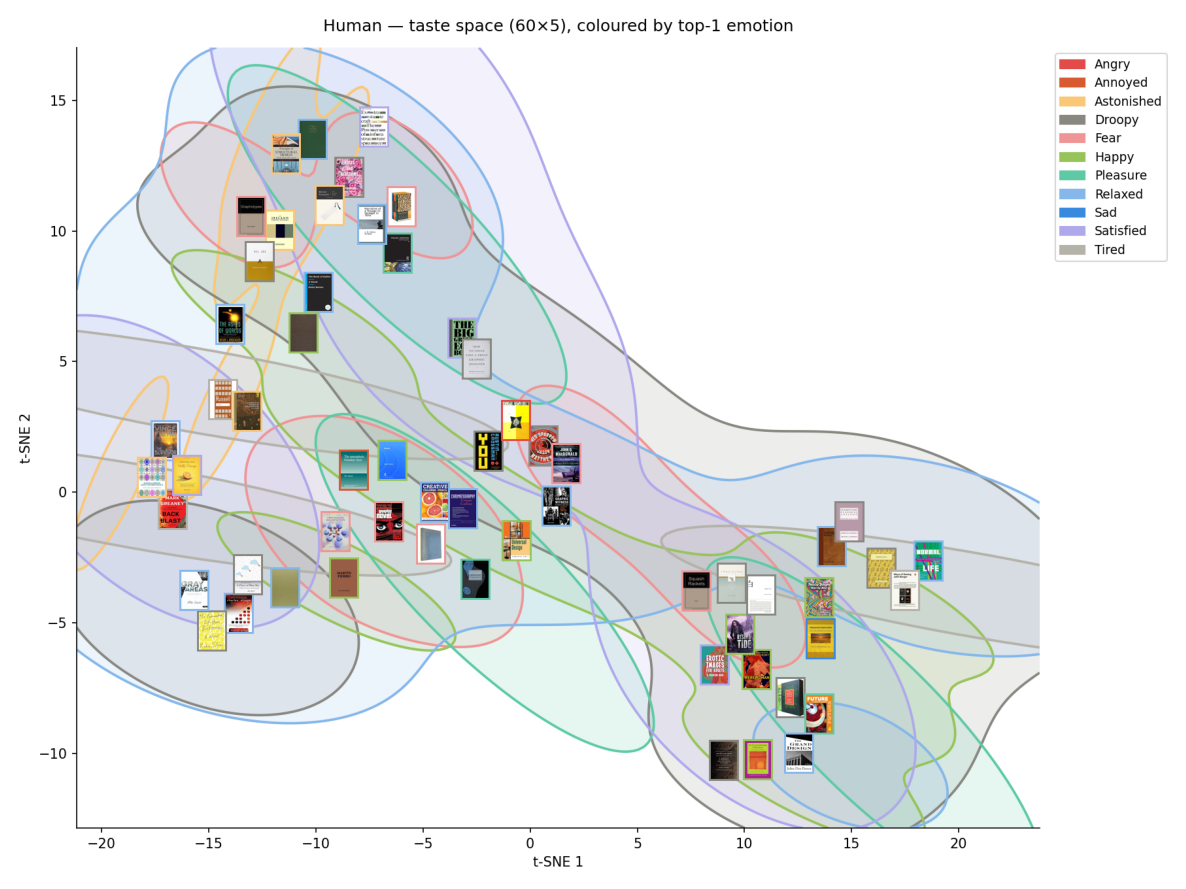

In [ ]:
# Human study on emotion space
tsne_with_covers(coords_human_ta, human_top1_emotion, EMOTION_PALETTE,
                 'Human — taste space (60×5), coloured by top-1 emotion',
                 human_taste_image_paths,
                 savefile='tsne_human_taste.png')

Feedback: Idea is good but it's not obvious > use shapes to show the differentiation

# Section 5 - Valence Arousal Space

In [ ]:
# ── VA coordinates (integer scale, from Russell circumplex diagram) ───────────
VA = {
    'astonished': ( 1,  3),
    'happy':      ( 2,  2),
    'pleasure':   ( 3,  1),
    'satisfied':  ( 3, -1),
    'relaxed':    ( 2, -2),
    'tired':      ( 1, -3),
    'droopy':     (-1, -3),
    'disgust':    (-2, -2),
    'sad':        (-3, -1),
    'annoyed':    (-3,  1),
    'angry':      (-2,  2),
    'fear':       (-1,  3),
}

va_coords = np.array([VA[e] for e in EMOTIONS_LOWER])  # (12, 2)

# Project each book into VA space using score distribution as weights
clip_va  = clip_emotion_probs  @ va_coords   # (60, 2)
human_va = human_emotion_probs @ va_coords   # (60, 2)

print(f'clip_va shape:  {clip_va.shape}')
print(f'human_va shape: {human_va.shape}')
print(f'Valence range  — CLIP:  [{clip_va[:,0].min():.2f}, {clip_va[:,0].max():.2f}]')
print(f'Arousal range  — CLIP:  [{clip_va[:,1].min():.2f}, {clip_va[:,1].max():.2f}]')
print(f'Valence range  — Human: [{human_va[:,0].min():.2f}, {human_va[:,0].max():.2f}]')
print(f'Arousal range  — Human: [{human_va[:,1].min():.2f}, {human_va[:,1].max():.2f}]')

clip_va shape:  (60, 2)
human_va shape: (60, 2)
Valence range  — CLIP:  [-0.13, 0.10]
Arousal range  — CLIP:  [-0.29, 0.13]
Valence range  — Human: [-1.27, 2.11]
Arousal range  — Human: [-2.21, 2.18]


Saved: va_clip_taste.png


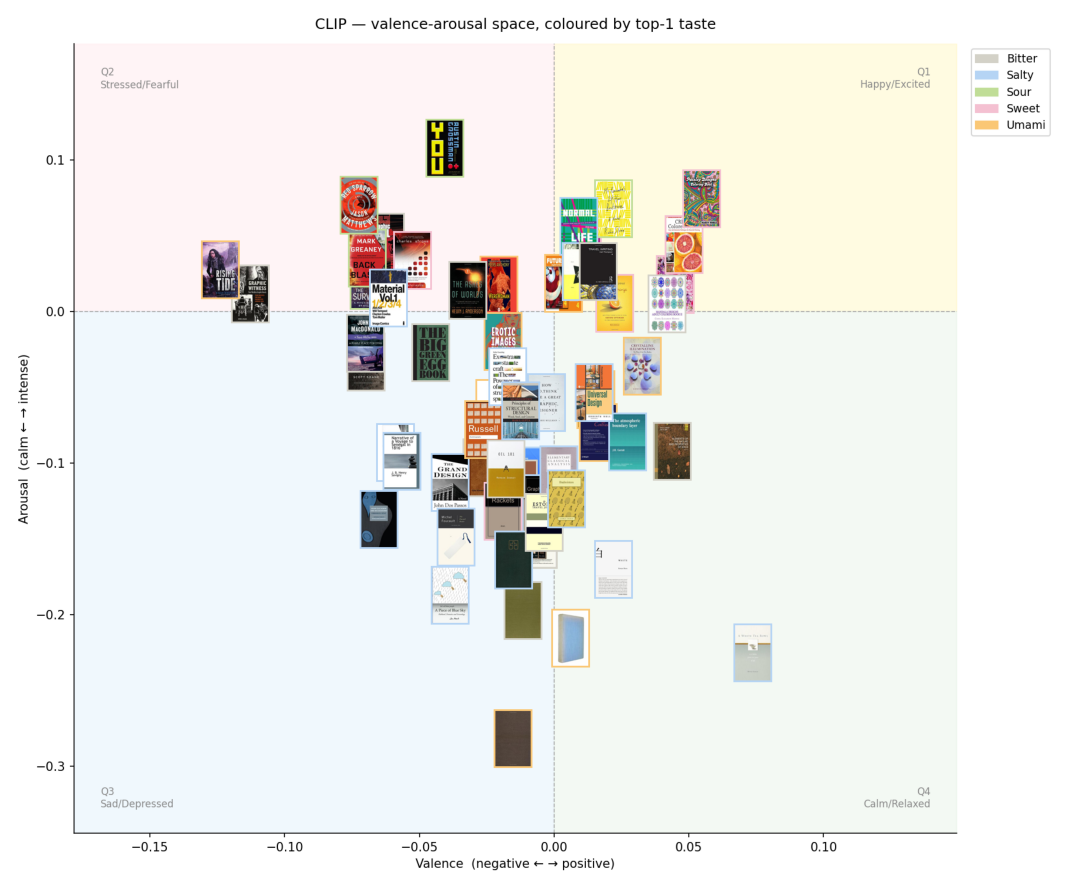

In [ ]:
# VA plot 1: CLIP, coloured by taste
plot_va_covers(
    clip_va, clip_top1_taste,
    TASTE_PALETTE,
    'CLIP — valence-arousal space, coloured by top-1 taste',
    pool_image_paths,
    savefile='va_clip_taste.png'
)

Saved: va_human_taste.png


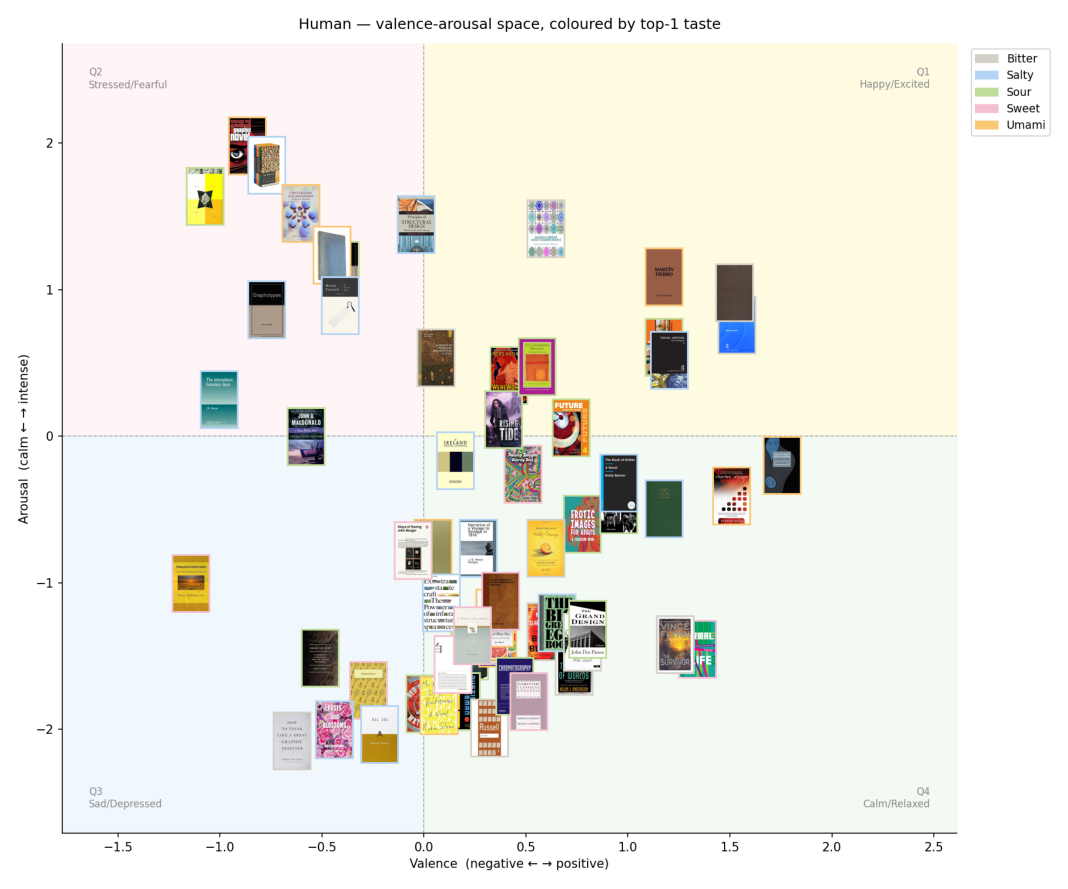

In [ ]:
# VA plot 2: Human, coloured by taste
plot_va_covers(
    human_va, human_top1_taste,
    TASTE_PALETTE,
    'Human — valence-arousal space, coloured by top-1 taste',
    human_emotion_image_paths,
    savefile='va_human_taste.png',
    padding=0.5
)

# Section 5 — Agreement analysis
Probability-based agreement, binomial test, Jensen-Shannon Divergence

In [ ]:
# P(agreement): probability humans assigned to CLIP's top-1 emotion
emotion_agreement = []
for i, ai_label in enumerate(clip_top1_emotion):
    label_idx = EMOTIONS_LOWER.index(ai_label.lower())
    emotion_agreement.append(human_emotion_probs[i, label_idx])

# P(agreement): probability humans assigned to CLIP's top-1 taste
taste_agreement = []
for i, ai_label in enumerate(clip_top1_taste):
    label_idx = TASTES_LOWER.index(ai_label.lower())
    taste_agreement.append(human_taste_probs[i, label_idx])

print(f'Emotion agreement — mean: {np.mean(emotion_agreement):.2%}  '
      f'median: {np.median(emotion_agreement):.2%}  '
      f'chance baseline: {1/len(EMOTIONS):.2%}')
print(f'Taste agreement   — mean: {np.mean(taste_agreement):.2%}  '
      f'median: {np.median(taste_agreement):.2%}  '
      f'chance baseline: {1/len(TASTES):.2%}')

Emotion agreement — mean: 9.49%  median: 6.45%  chance baseline: 8.33%
Taste agreement   — mean: 21.25%  median: 18.75%  chance baseline: 20.00%


In [ ]:
js_distances = []
for i in range(N_BOOKS):
    # Compare human vector vs AI vector for book 'i'
    distance = jensenshannon(human_emotion_probs[i], clip_emotion_probs[i])
    js_distances.append(distance)

print(f"Average JS Divergence: {np.mean(js_distances):.4f}")

Average JS Divergence: 0.3673


In [ ]:
from scipy.stats import chi2_contingency
import warnings

def run_chi_square_analysis(matrix, labels, analysis_name):
    """
    matrix: (n_books, n_labels) — works with both binary and probability matrices.
    Filters out all-zero rows before running chi-square.
    """
    # Remove books where all values are 0 (no votes / no assignment)
    row_sums = matrix.sum(axis=1)
    valid    = row_sums > 0
    matrix   = matrix[valid]
    n_removed = (~valid).sum()
    if n_removed > 0:
        print(f'  Note: removed {n_removed} books with all-zero rows')

    observed = matrix.T  # (n_labels, n_books)

    # Add tiny epsilon to avoid zero expected frequencies
    observed_safe = observed + 1e-8

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        chi2, p, dof, expected = chi2_contingency(observed_safe)

    # Standardised residuals
    with np.errstate(divide='ignore', invalid='ignore'):
        std_residuals = np.where(
            expected > 0,
            (observed - expected) / np.sqrt(expected),
            0
        )

    df_residuals = pd.DataFrame(
        std_residuals,
        index=labels,
        columns=[f'B{i+1:02d}' for i in range(matrix.shape[0])]
    )

    print(f'\n {analysis_name}')
    print(f'Chi-square statistic: {chi2:.4f}')
    print(f'p-value:              {p:.4e}')
    print(f'Degrees of freedom:   {dof}')
    print(f'Significant (p<0.05): {"YES ✓" if p < 0.05 else "NO ✗"}')

    strong_pos = [(lab, f'B{b+1:02d}', round(df_residuals.iloc[j, b], 3))
                  for j, lab in enumerate(labels)
                  for b in range(matrix.shape[0])
                  if df_residuals.iloc[j, b] > 2]
    strong_neg = [(lab, f'B{b+1:02d}', round(df_residuals.iloc[j, b], 3))
                  for j, lab in enumerate(labels)
                  for b in range(matrix.shape[0])
                  if df_residuals.iloc[j, b] < -2]

    strong_pos.sort(key=lambda x: -x[2])
    strong_neg.sort(key=lambda x:  x[2])

    print(f'\nStrongest positive associations (residual > +2): {len(strong_pos)}')
    for label, book, val in strong_pos[:10]:
        print(f'  {label:12s} × {book}  →  +{val}')

    if strong_neg:
        print(f'\nStrongest negative associations (residual < -2): {len(strong_neg)}')
        for label, book, val in strong_neg[:5]:
            print(f'  {label:12s} × {book}  →  {val}')

    return chi2, p, dof, df_residuals


# Use probability matrices — richer signal than binary
chi2_clip_em,  p_clip_em,  dof_clip_em,  resid_clip_em  = run_chi_square_analysis(
    clip_emotion_probs,  EMOTIONS, 'CLIP — emotion (probability)')

chi2_clip_ta,  p_clip_ta,  dof_clip_ta,  resid_clip_ta  = run_chi_square_analysis(
    clip_taste_probs,    TASTES,   'CLIP — taste (probability)')

chi2_human_em, p_human_em, dof_human_em, resid_human_em = run_chi_square_analysis(
    human_emotion_probs, EMOTIONS, 'Human — emotion (probability)')

chi2_human_ta, p_human_ta, dof_human_ta, resid_human_ta = run_chi_square_analysis(
    human_taste_probs,   TASTES,   'Human — taste (probability)')


 CLIP — emotion (probability)
Chi-square statistic: 0.3279
p-value:              1.0000e+00
Degrees of freedom:   649
Significant (p<0.05): NO ✗

Strongest positive associations (residual > +2): 0

 CLIP — taste (probability)
Chi-square statistic: 0.3453
p-value:              1.0000e+00
Degrees of freedom:   236
Significant (p<0.05): NO ✗

Strongest positive associations (residual > +2): 0

 Human — emotion (probability)
Chi-square statistic: 72.0099
p-value:              1.0000e+00
Degrees of freedom:   649
Significant (p<0.05): NO ✗

Strongest positive associations (residual > +2): 2
  Sad          × B34  →  +2.171
  Fear         × B06  →  +2.11

 Human — taste (probability)
Chi-square statistic: 32.3221
p-value:              1.0000e+00
Degrees of freedom:   236
Significant (p<0.05): NO ✗

Strongest positive associations (residual > +2): 0


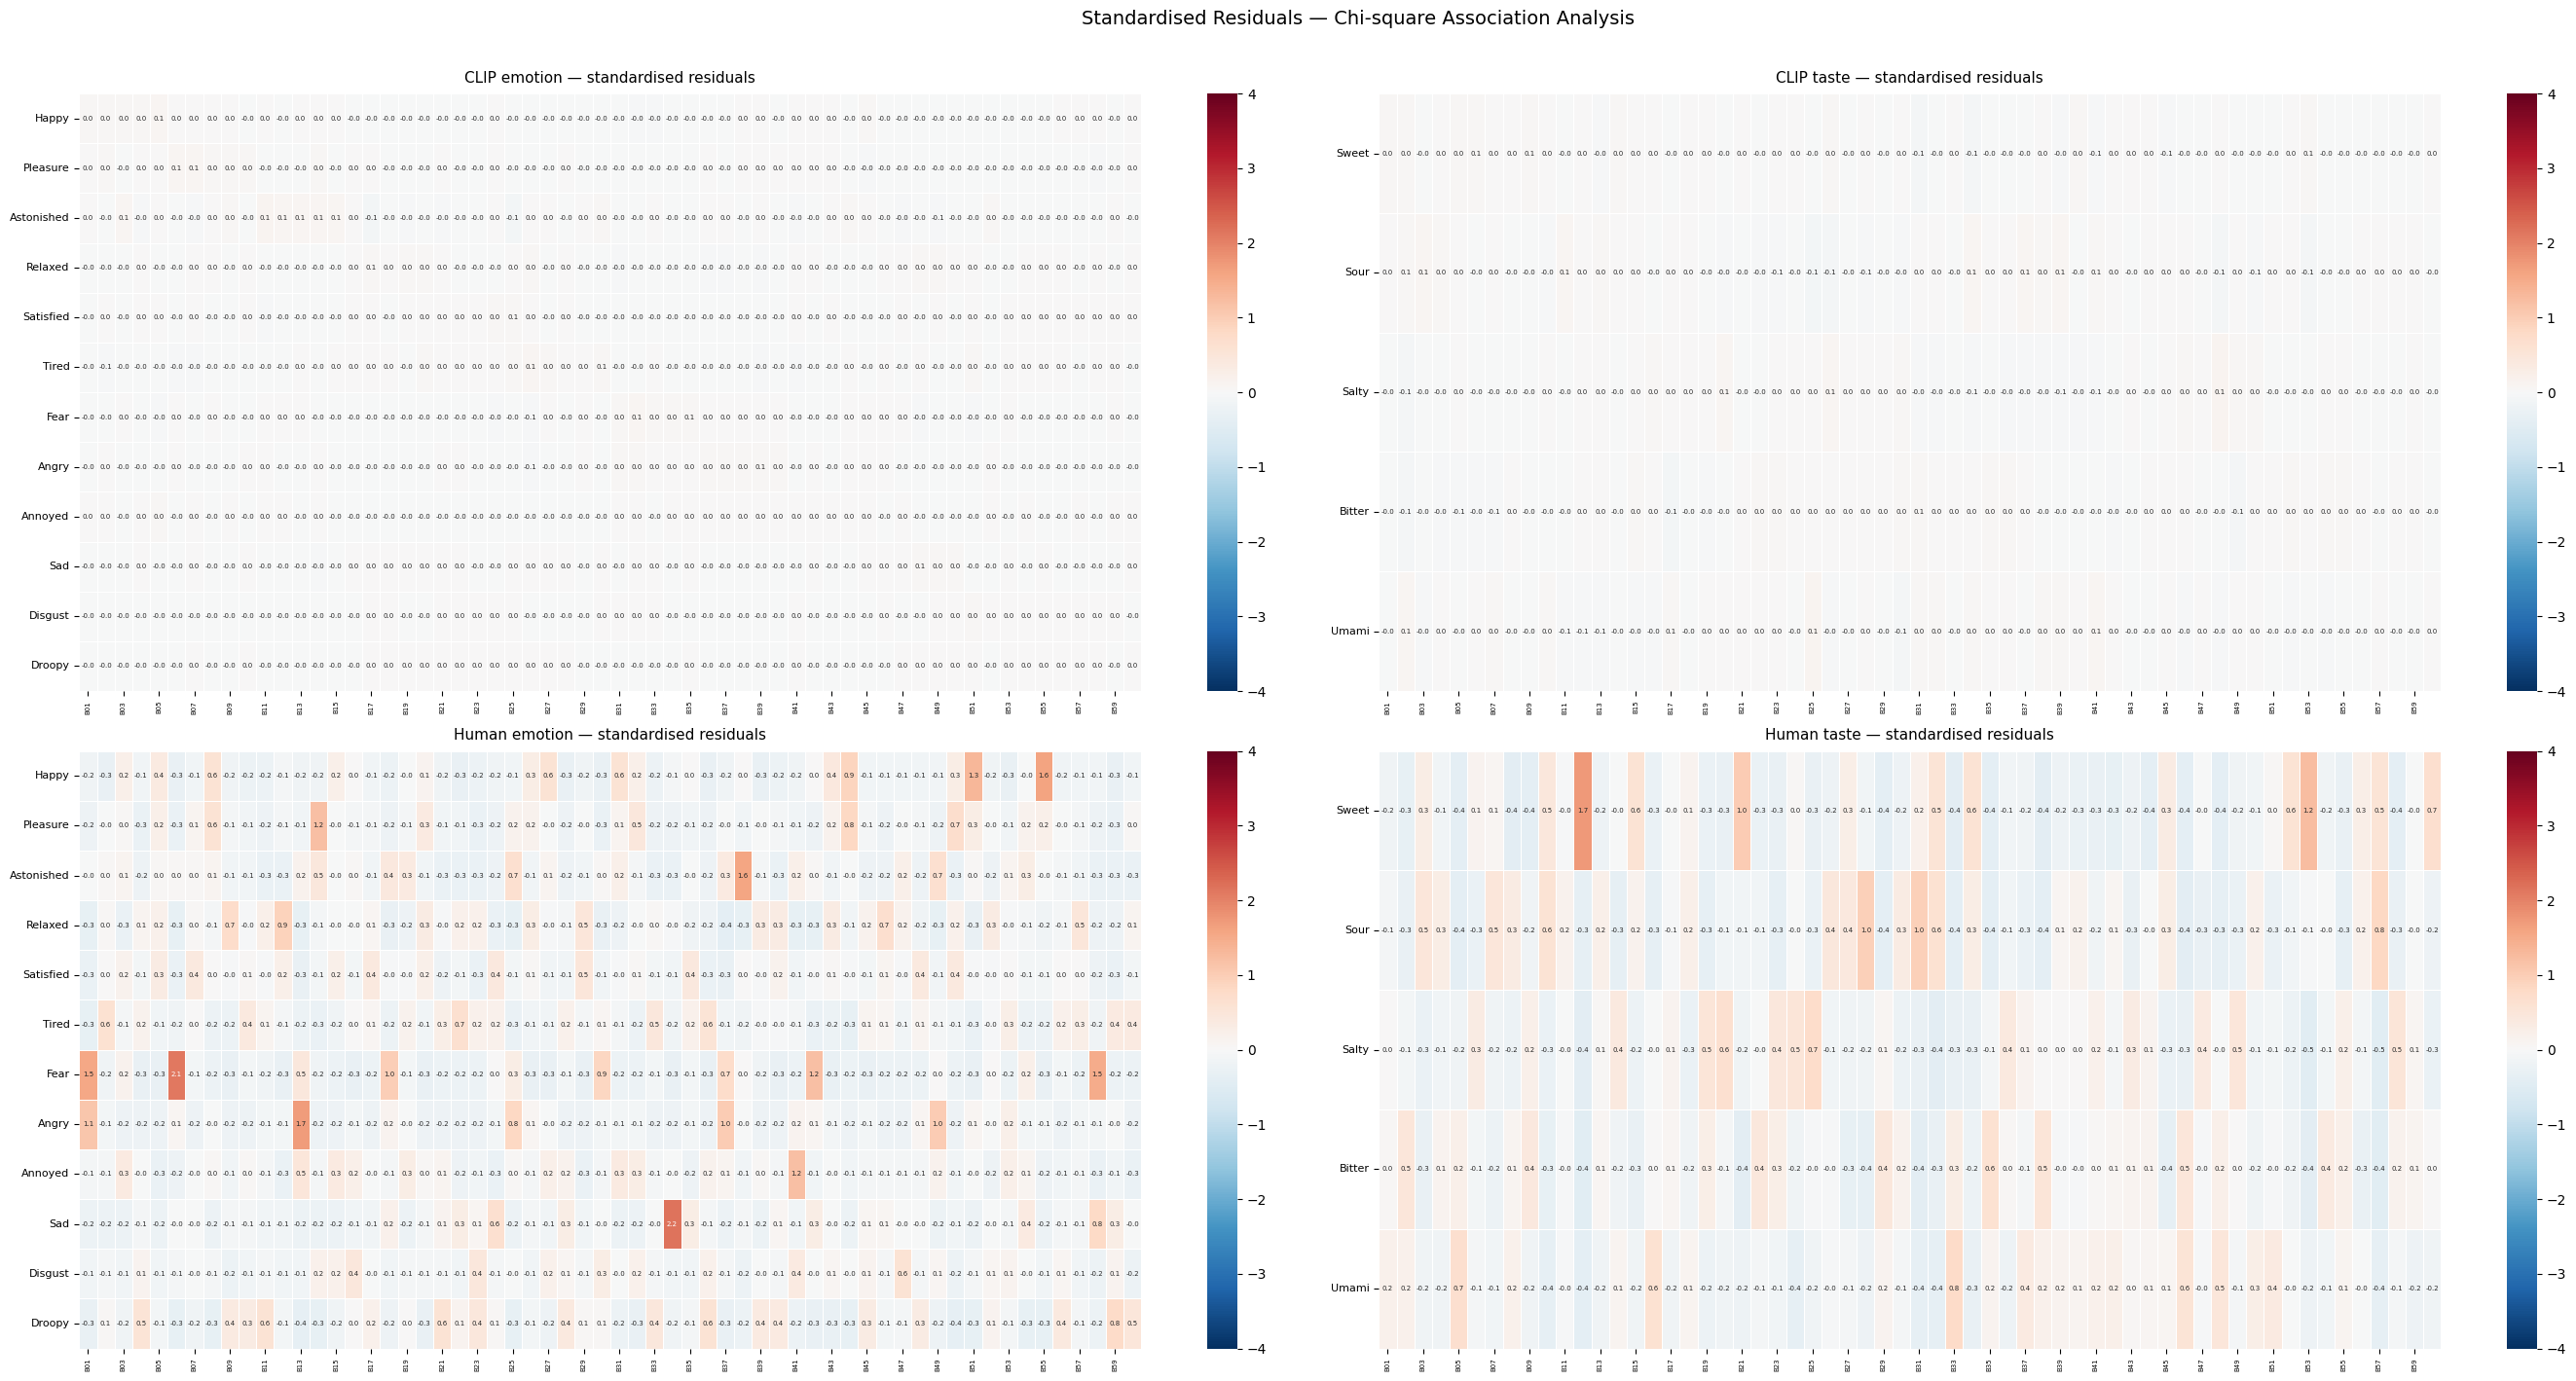

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(28, 14))

datasets = [
    (resid_clip_em,  'CLIP emotion — standardised residuals'),
    (resid_clip_ta,  'CLIP taste — standardised residuals'),
    (resid_human_em, 'Human emotion — standardised residuals'),
    (resid_human_ta, 'Human taste — standardised residuals'),
]

for ax, (df, title) in zip(axes.flat, datasets):
    sns.heatmap(df, ax=ax, annot=True, fmt='.1f', annot_kws={'size': 5},
                cmap='RdBu_r', center=0, vmin=-4, vmax=4,
                linewidths=0.4, linecolor='white', cbar=True)
    ax.set_title(title, fontsize=11, pad=8)
    ax.tick_params(axis='x', rotation=90, labelsize=5)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Standardised Residuals — Chi-square Association Analysis',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('chi_square_residuals.png', dpi=150, bbox_inches='tight')
plt.show()